# What is Spark UI?

The Spark UI is a web-based interface that provides insights into the performance and behavior of Spark applications. It is useful for developers, data scientists, and other stakeholders who need to monitor and optimize their Spark applications. It is by default hosted at port 4040.

Here are the main components of the Spark UI:

1. Jobs: The Jobs tab displays information about the individual jobs in the application, including their status, duration, and resource usage.

2. Stages: The Stages tab provides a breakdown of each job into its individual stages, showing their status, duration, and resource usage.

3. Storage: The Storage tab shows the status of the Spark RDD (Resilient Distributed Datasets) storage, including the size of the RDD and the amount of memory used for caching.

4. Environment: The Environment tab shows the configuration and environment variables used in the Spark application.

5. Executors: The Executors tab displays information about the executors used in the application, including their resource usage and task execution times.

6. SQL/Dataframe: The SQL tab displays information about Spark SQL queries executed by the application, including their duration and resource usage.



These components are designed to provide a comprehensive view of the Spark application's performance, resource usage, and overall behavior, helping developers to optimize their applications and improve their performance.

**REFERENCE**: https://spark.apache.org/docs/latest/web-ui.html

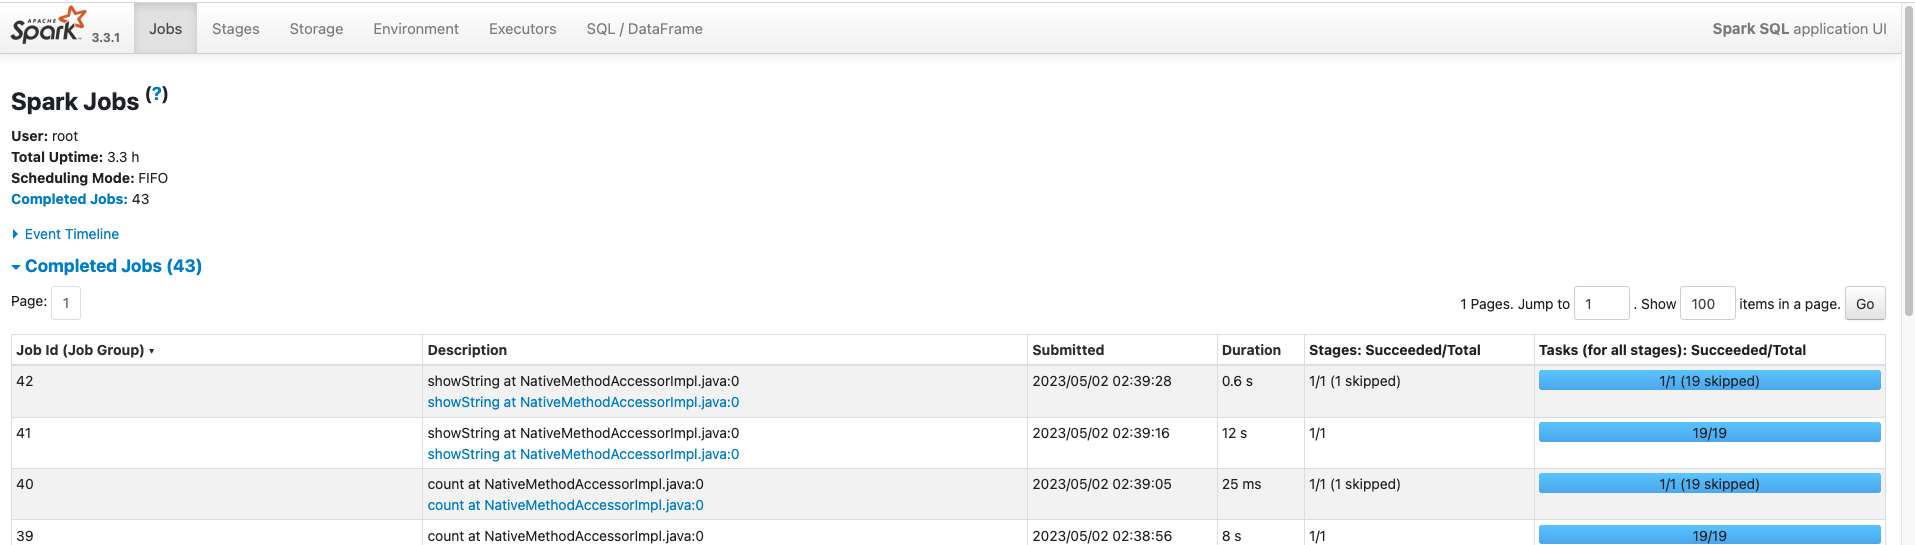

### Start Spark Session

In [ ]:
# Suppress native-hadoop warning
!sed -i '$a\# Add the line for suppressing the NativeCodeLoader warning \nlog4j.logger.org.apache.hadoop.util.NativeCodeLoader=ERROR,console' /$HADOOP_HOME/etc/hadoop/log4j.properties
import os; os.close(os.dup2(os.open(os.devnull, os.O_WRONLY), 2))

In [ ]:
!hdfs dfs -copyFromLocal courses.csv  /courses.csv
!hdfs dfs -copyFromLocal professors.csv  /professors.csv

In [ ]:
import pyspark
from pyspark.sql import SparkSession

conf = pyspark.SparkConf().setAll([
    ('spark.master', 'local[2]'),
    ('spark.app.name', 'Spark SQL'),
    ('spark.driver.host', 'localhost'), 
])
spark = SparkSession.builder.config(conf=conf).getOrCreate()

In [ ]:
spark 

### Load the required dataframes from HDFS

In [ ]:
courses = spark.read.format("csv").option("header","true").load('hdfs:///courses.csv').cache()  #Job ID 0
professors = spark.read.format("csv").option("header","true").load('hdfs:///professors.csv').cache() #Job ID 1

In [ ]:
print(courses.rdd.getNumPartitions())
print(professors.rdd.getNumPartitions())

### Environment Tab - The Environment tab shows the configuration and environment variables used in the Spark application.

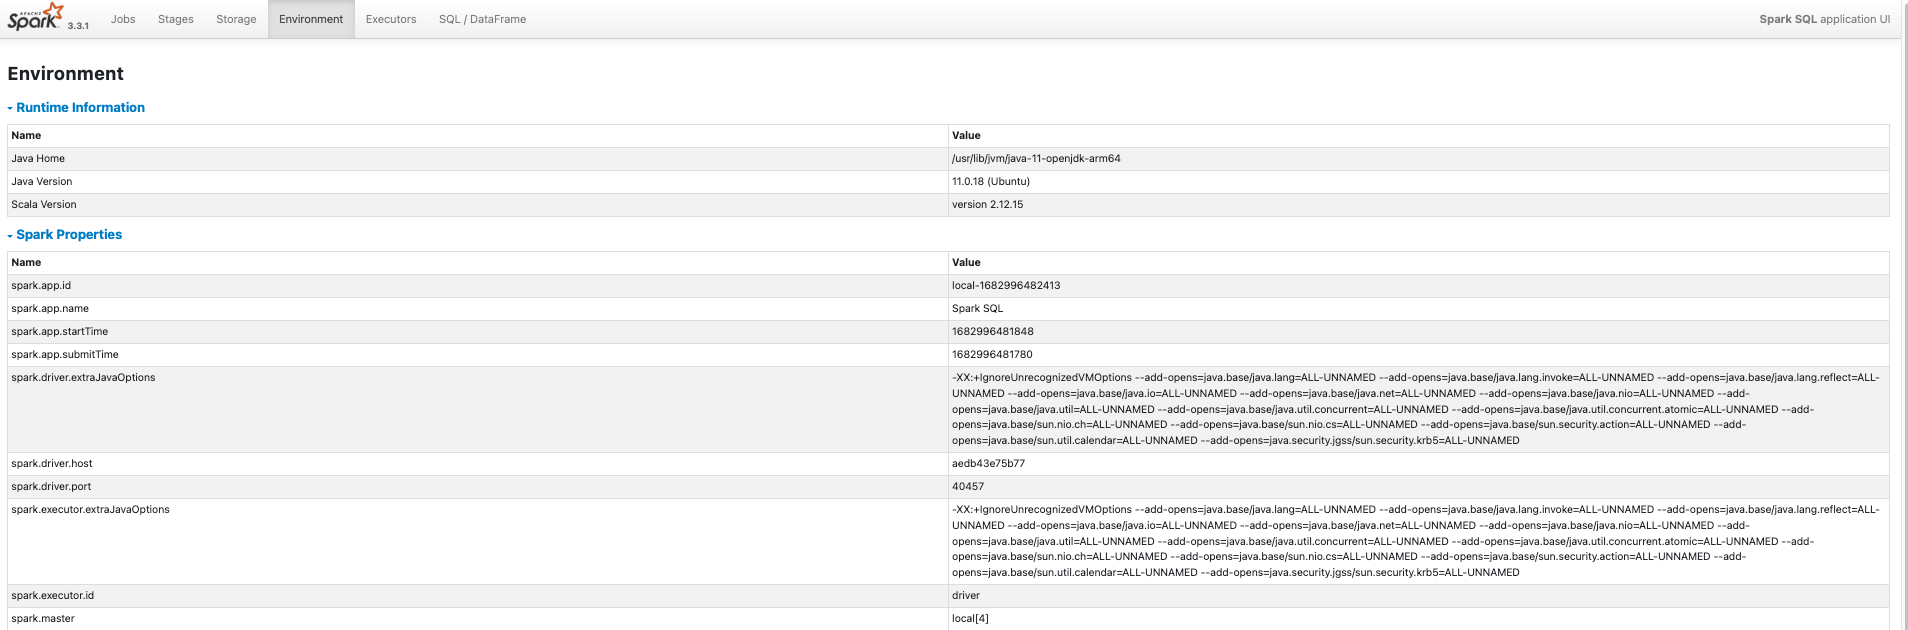

### Storage Tab-The Storage tab shows the status of the Spark RDD (Resilient Distributed Datasets) storage, including the size of the RDD and the amount of memory used for caching.

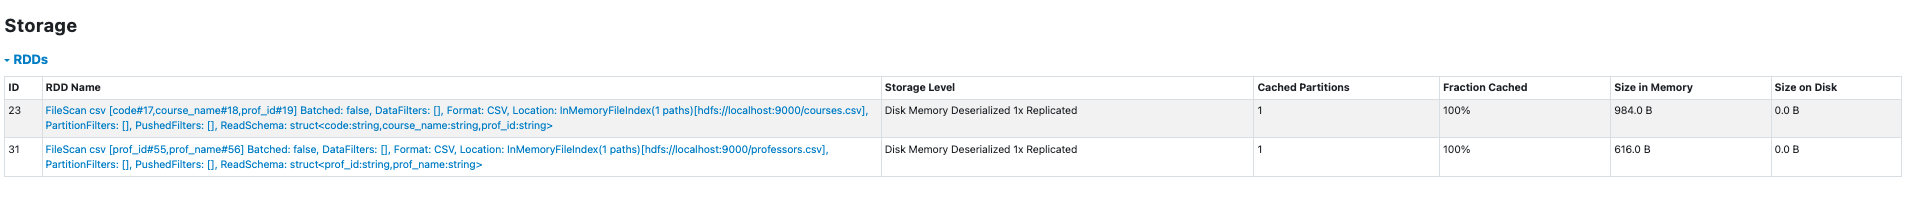

In [ ]:
courses.show(truncate=False) #Job ID 2

In [ ]:
professors.show(truncate=False) #Job ID 3

###  Executors Tab - The Executors tab displays information about the executors used in the application, including their resource usage and task execution times.

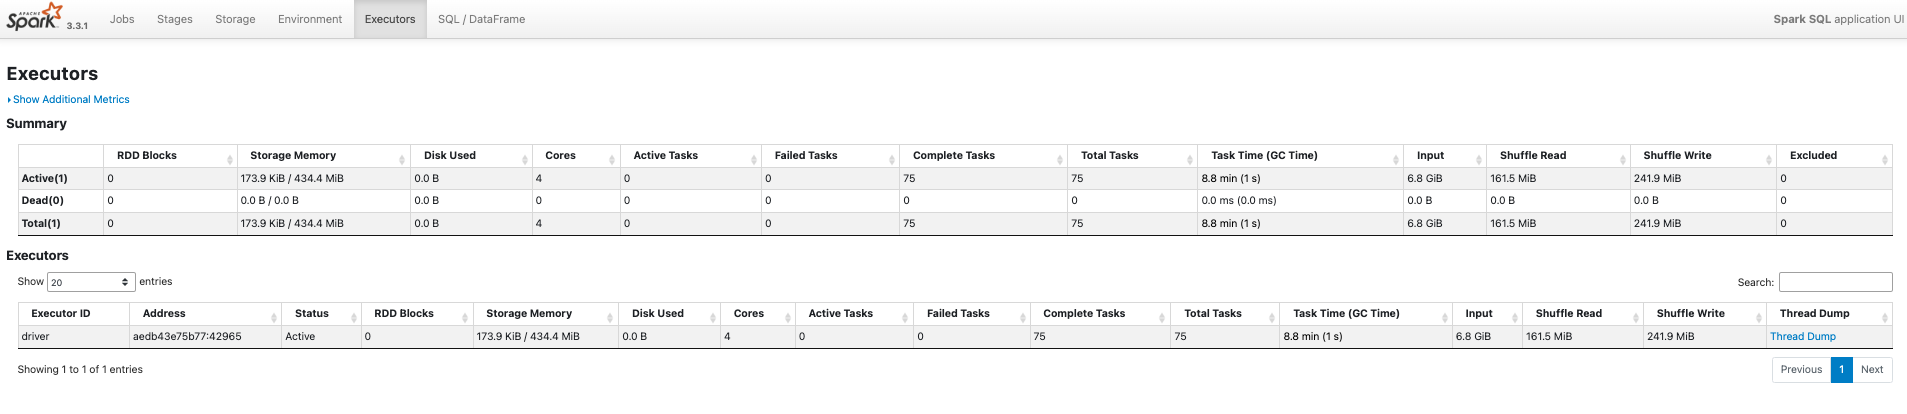

### SQL TAB - The SQL tab displays information about Spark SQL queries executed by the application, including their duration and resource usage.

In [ ]:
courses.join(professors,"prof_id",how="inner").select("code","course_name","prof_id","prof_name").explain() #Job ID 4

In [ ]:
courses.join(professors,"prof_id",how="inner").select("code","course_name","prof_id","prof_name").show(truncate=False)  #Job ID 5

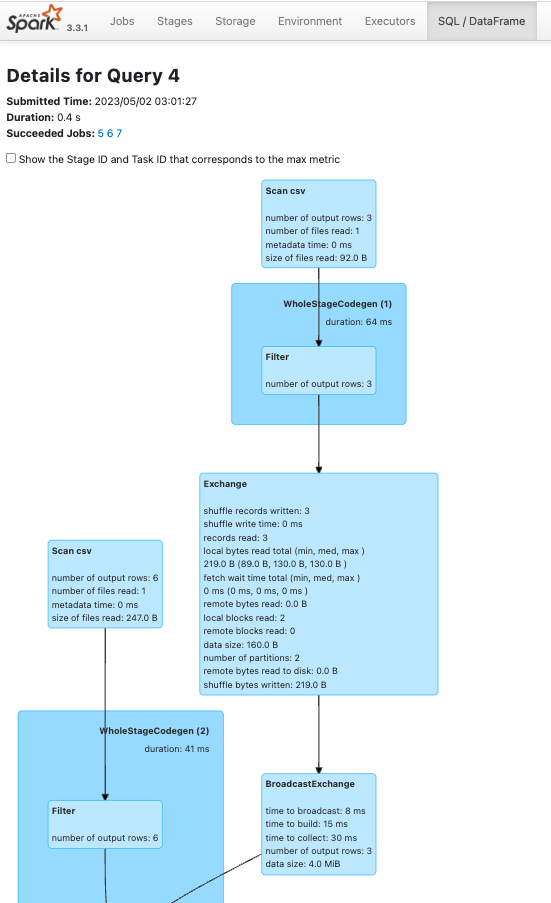

### Job vs Stage Vs Task

**Job**: A Job is a high-level unit of work in Apache Spark that represents a single batch computation consisting of multiple stages. A Job is typically submitted to the SparkContext by a user program, and it consists of multiple stages that are executed sequentially. A Job can be thought of roughly as one spark action although you may find extra jobs created by Spark's optimization engine.

**Stage**: A Stage is an intermediate step in a Spark Job that represents a set of tasks that can be executed in parallel. A Stage is typically created by the Spark runtime system during the optimization process, where it groups together tasks that can be executed together on the same set of data. A Stage is defined by the set of transformations and actions that need to be executed, and it represents a point in the computation where data is shuffled between nodes.

**Task**: A Task is the smallest unit of work in Apache Spark that represents a single unit of computation that can be executed on a single partition of data. A Task is typically created by the Spark runtime system during the execution phase, where it represents a single unit of work that can be executed by a single worker node. Each Task is executed on a single partition of data and is allocated to 1 core for processing.

To summarize, a Job is a high-level unit of work that consists of multiple stages, each of which represents a set of tasks that can be executed in parallel. A Stage is an intermediate step in a Job that groups together tasks that can be executed together on the same set of data. A Task is the smallest unit of work that represents a single unit of computation that can be executed on a single partition of data.

#### READING, FILTERING AND COUNTING

In [ ]:
from pyspark.sql.types import StructType, StructField, StringType, FloatType

df = spark.read.load('file:///home/work/2026/S3/Demo3B-SparkUI-DaskUI/Airline_2016_2018.csv', 
                     format="csv", header="true", inferSchema="true") \
           .select('OP_CARRIER', 'ORIGIN', 'DEST', 'AIR_TIME') #Job ID 6 & 7

In [ ]:
df.show(10)   #Job ID 8 
print('Number of partitions=',df.rdd.getNumPartitions()) # # of Partitions = (File Size / partiton max size(128MB by default))=(2.43GB*1024)/128 = 19

In [ ]:
df.count() #Job ID 9 & 10 (stage 10 skipped)

In [ ]:
df = df.filter(df.AIR_TIME < 360) #Job ID 11
df.count() #Job ID 12 ( stage 13 skipped )

#### WINDOW PARTITION PROCESSING

In [ ]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number
from pyspark.sql.functions import rank,dense_rank
from pyspark.sql.functions import avg,col

windowPartitionAvg = Window.partitionBy("OP_CARRIER")


In [ ]:
df.withColumn("Avg Flight Time Per Carrier",avg(col("AIR_TIME")).over(windowPartitionAvg)).sort("Avg Flight Time Per Carrier").show() #Job ID 13& 14 (16 skipped)

### WRITING TO PARQUET

In [ ]:
df.repartition(4).write.parquet('/filtered_df', mode="overwrite") #Job ID 15 & 16 (Stage 19 skipped)

In [ ]:
!hdfs dfs -ls /filtered_df

### Jobs Tab - The Jobs tab displays information about the individual jobs in the application, including their status, duration, and resource usage.

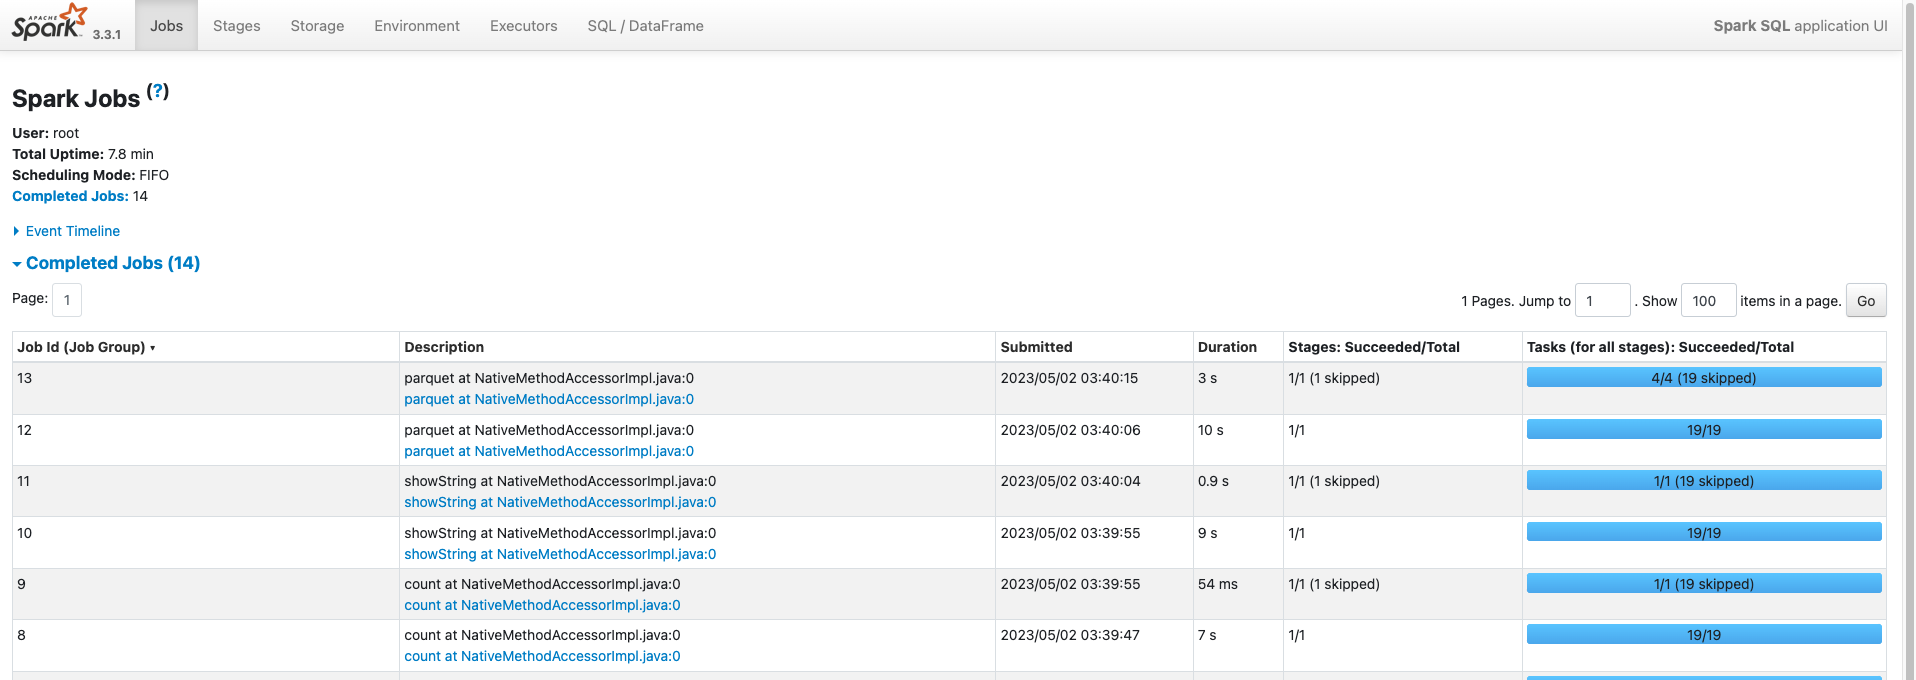

#### STAGES TAB - The Stages tab provides a breakdown of each job into its individual stages, showing their status, duration, and resource usage.

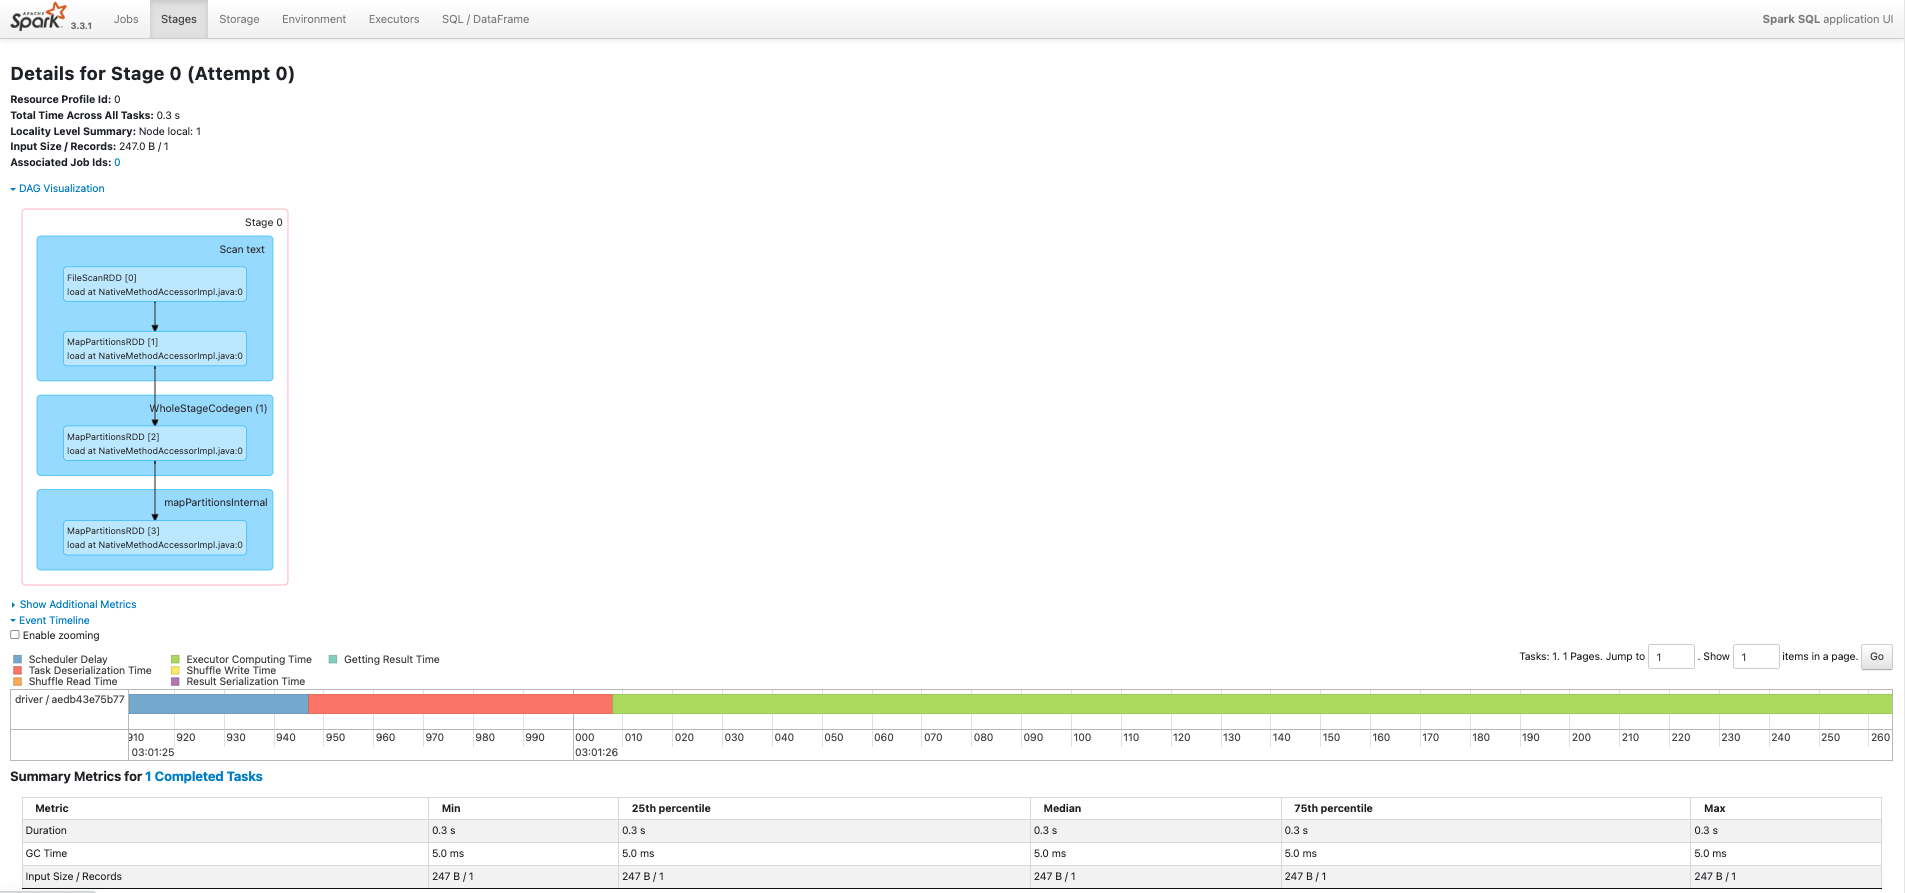

#### Note
In Apache Spark, a skipped job or stage in the Spark UI indicates that the Spark runtime system has determined that the job or stage is not necessary for the computation.

When a job or stage is submitted to the Spark runtime system, it goes through an optimization process that determines the most efficient way to execute the computation. During this optimization process, the Spark runtime system may determine that some jobs or stages can be skipped because their output is not required or because they can be combined with other jobs or stages.

If a job or stage is skipped, it will not be executed by the Spark runtime system, and its status in the Spark UI will be marked as "Skipped". The resources that would have been used to execute the skipped job or stage are then allocated to other jobs or stages, which can improve the overall performance of the Spark application.

In [ ]:
spark.stop()